## Problem Statement: Bike Rental Demand Prediction

The objective of this project is to develop a predictive model to estimate the number of bikes rented in a given time period. The target variable, rented bike count, is numerical in nature, making this a regression problem.

The model will utilize various independent variables such as weather conditions (temperature, humidity, wind speed), seasonal factors, time-related features (hour, day, month), and possibly other environmental or temporal attributes to predict the demand for rental bikes.

Accurate prediction of bike rental demand can help businesses and service providers optimize resource allocation, improve customer satisfaction, and reduce operational inefficiencies.

#### target is == rented bike count
#### target is numerical is nature so its a regression problem 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import statsmodels.formula.api as smf
from sklearn.feature_selection import SelectKBest, f_regression 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
from sklearn.linear_model import Lasso,Ridge,ElasticNet

In [2]:
df = pd.read_csv("SeoulBikeData.csv" , encoding='unicode_escape')

In [3]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.shape

(8760, 14)

In [5]:
df.columns = df.columns.str.replace(' ', '_')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented_Bike_Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind_speed_(m/s)           8760 non-null   float64
 6   Visibility_(10m)           8760 non-null   int64  
 7   Dew_point_temperature(°C)  8760 non-null   float64
 8   Solar_Radiation_(MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall_(cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning_Day            8760 non-null   objec

In [7]:
df['Date']=pd.to_datetime(df.Date,format='%d/%m/%Y')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented_Bike_Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind_speed_(m/s)           8760 non-null   float64       
 6   Visibility_(10m)           8760 non-null   int64         
 7   Dew_point_temperature(°C)  8760 non-null   float64       
 8   Solar_Radiation_(MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall_(cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   object        
 12  Holida

In [9]:
df_cat = df.select_dtypes(include='object')

In [10]:
for i in df_cat:
    print(df[i].value_counts())
    print('\n')

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64


Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64


Functioning_Day
Yes    8465
No      295
Name: count, dtype: int64




In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,8760,2018-05-31 23:59:59.999999744,2017-12-01 00:00:00,2018-03-02 00:00:00,2018-06-01 00:00:00,2018-08-31 00:00:00,2018-11-30 00:00:00,NaN
Rented_Bike_Count,8760.0,704.602055,0.0,191.0,504.5,1065.25,3556.0,644.997468
Hour,8760.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922582
Temperature(°C),8760.0,12.882922,-17.8,3.5,13.7,22.5,39.4,11.944825
Humidity(%),8760.0,58.226256,0.0,42.0,57.0,74.0,98.0,20.362413
Wind_speed_(m/s),8760.0,1.724909,0.0,0.9,1.5,2.3,7.4,1.0363
Visibility_(10m),8760.0,1436.825799,27.0,940.0,1698.0,2000.0,2000.0,608.298712
Dew_point_temperature(°C),8760.0,4.073813,-30.6,-4.7,5.1,14.8,27.2,13.060369
Solar_Radiation_(MJ/m2),8760.0,0.569111,0.0,0.0,0.01,0.93,3.52,0.868746
Rainfall(mm),8760.0,0.148687,0.0,0.0,0.0,0.0,35.0,1.128193


In [12]:
df.describe(include='object').T

,count,unique,top,freq
Seasons,8760,4,Spring,2208
Holiday,8760,2,No Holiday,8328
Functioning_Day,8760,2,Yes,8465


In [13]:
df.isnull().sum()

Date                         0
Rented_Bike_Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind_speed_(m/s)             0
Visibility_(10m)             0
Dew_point_temperature(°C)    0
Solar_Radiation_(MJ/m2)      0
Rainfall(mm)                 0
Snowfall_(cm)                0
Seasons                      0
Holiday                      0
Functioning_Day              0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

# univariate and bivariate analysis

In [16]:
cont_df = df.select_dtypes(include='number')

In [17]:
cont_df.columns

Index(['Rented_Bike_Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind_speed_(m/s)', 'Visibility_(10m)', 'Dew_point_temperature(°C)',
       'Solar_Radiation_(MJ/m2)', 'Rainfall(mm)', 'Snowfall_(cm)'],
      dtype='object')

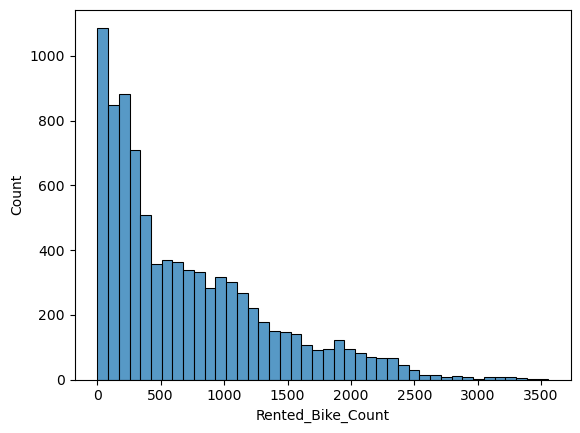

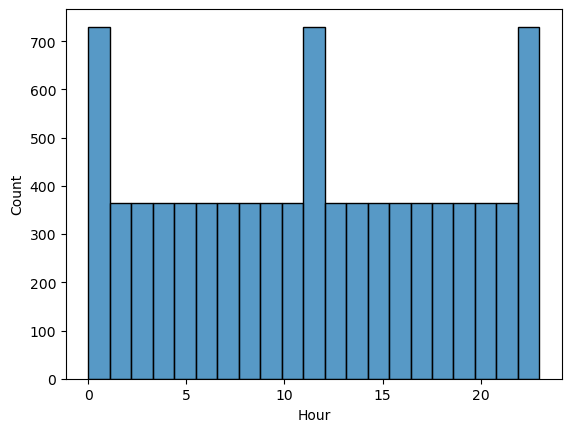

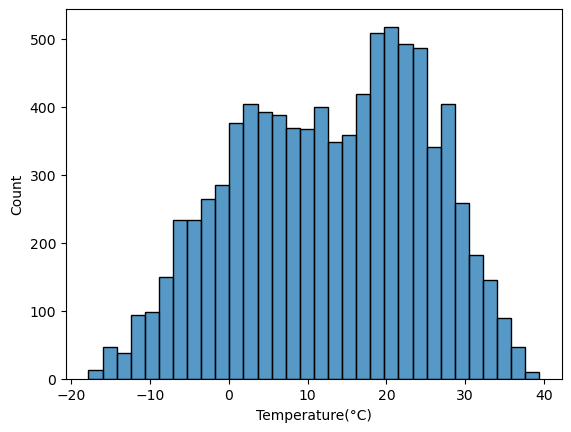

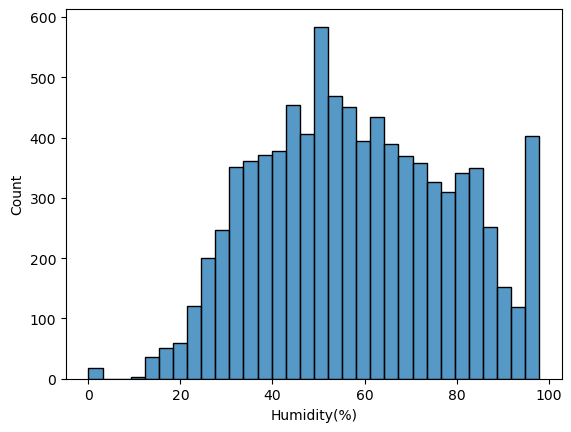

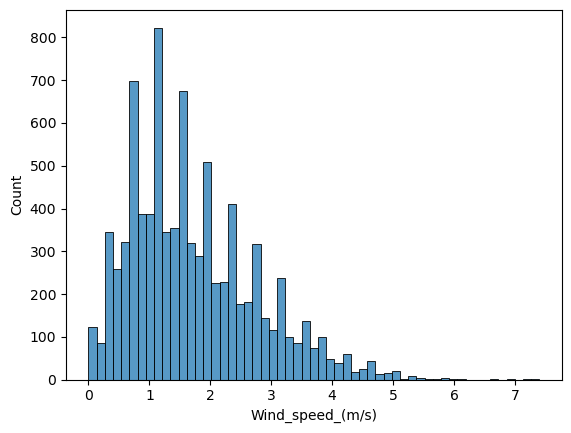

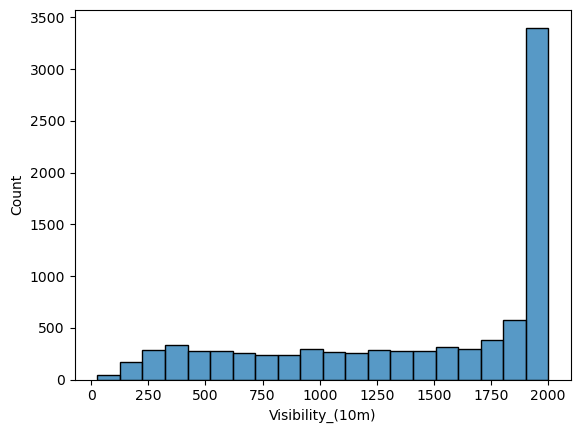

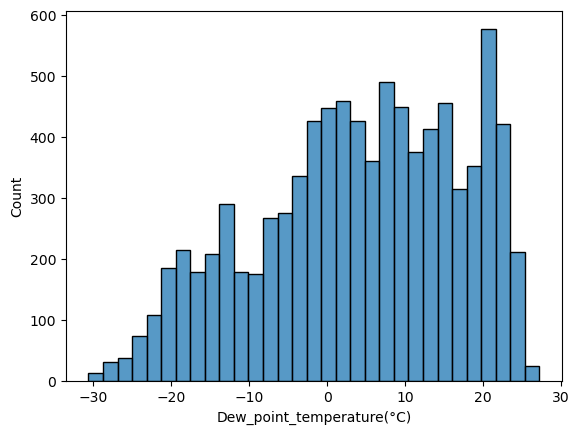

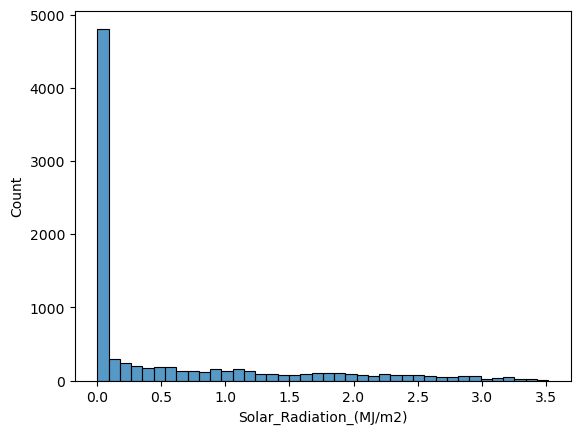

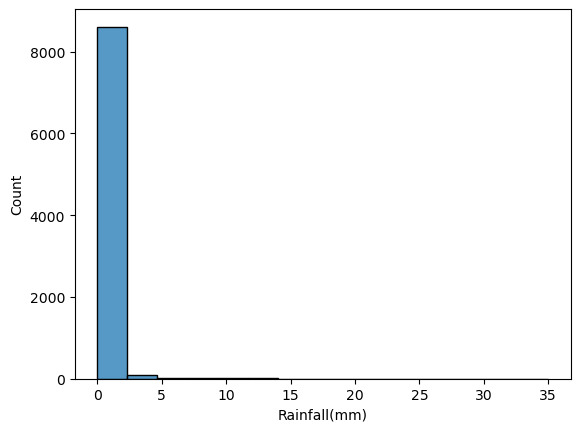

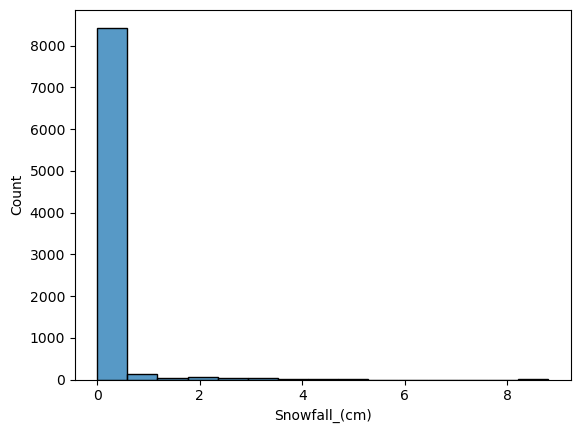

In [18]:
for i in cont_df:
    sns.histplot(data=df,x=i)
    plt.show()

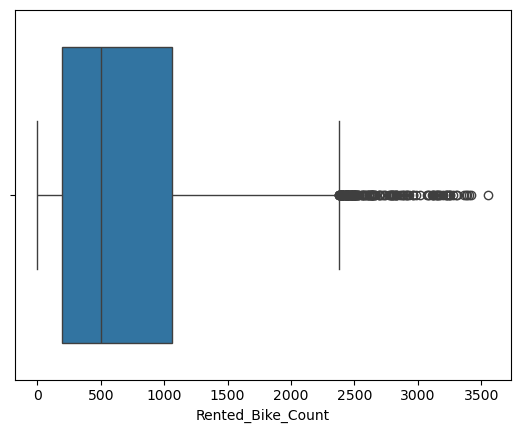

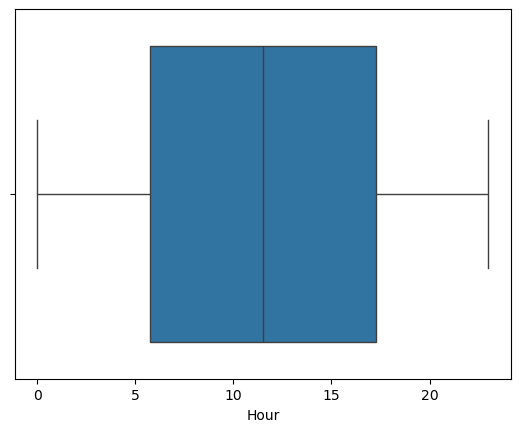

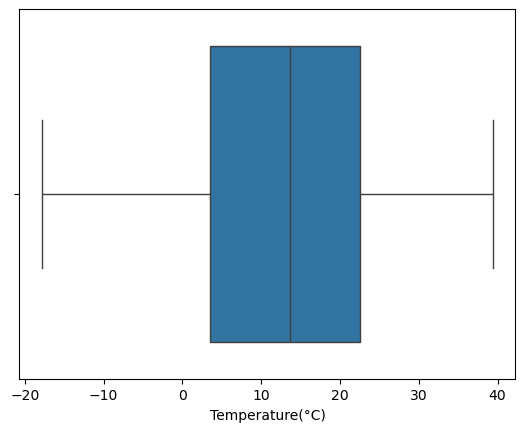

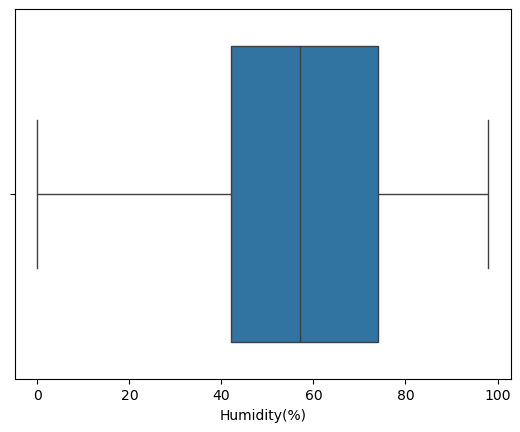

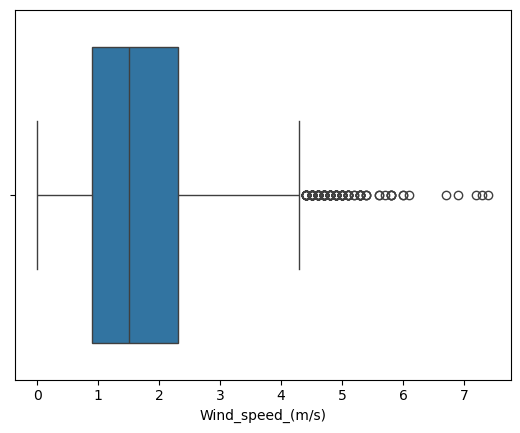

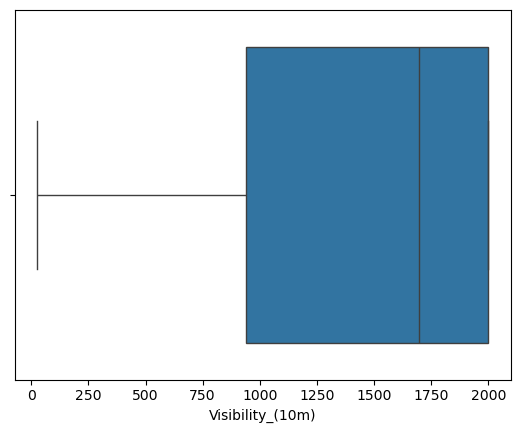

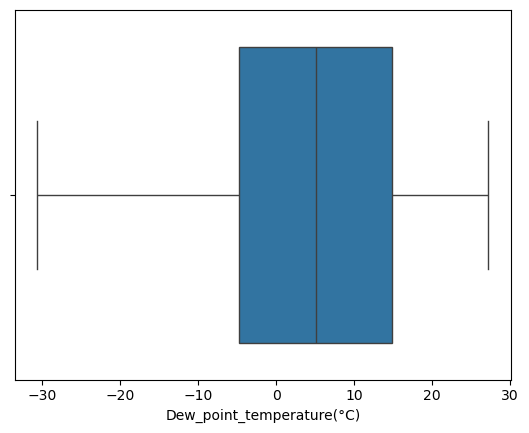

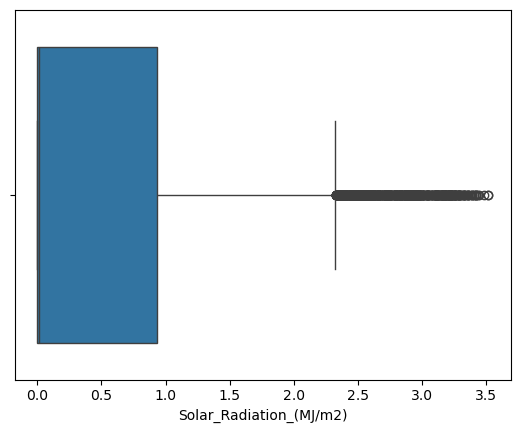

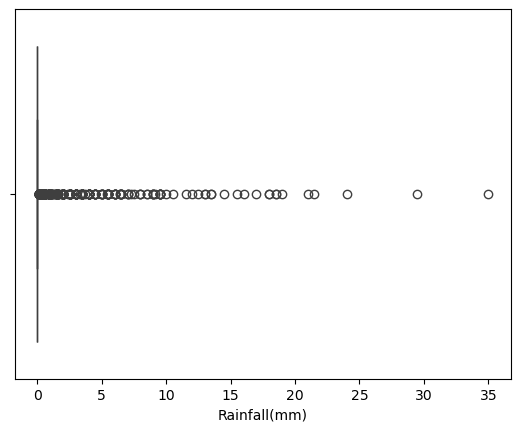

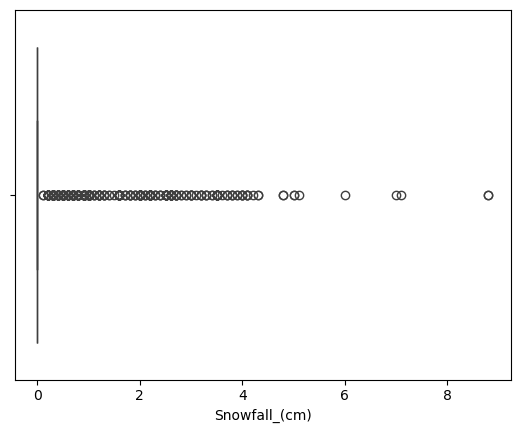

In [19]:
for i in cont_df:
    sns.boxplot(data=df,x=i)
    plt.show()

In [20]:
for i in ['Rainfall(mm)', 'Snowfall_(cm)']:
    print(df[i].value_counts())
    print('\n')

Rainfall(mm)
0.0     8232
0.5      116
1.0       66
1.5       56
0.1       46
        ... 
15.5       1
21.0       1
1.2        1
9.1        1
1.8        1
Name: count, Length: 61, dtype: int64


Snowfall_(cm)
0.0    8317
0.3      42
1.0      39
0.5      34
0.9      34
0.7      31
0.8      22
2.0      22
0.4      21
1.6      19
2.2      18
0.2      15
0.6      15
3.5      14
2.6      12
2.5      10
1.2       8
2.7       6
1.8       5
3.0       5
1.3       4
3.2       4
4.1       4
4.0       4
2.1       3
1.1       3
2.3       3
3.3       3
3.8       3
3.7       3
2.4       3
1.7       3
1.9       3
0.1       2
3.9       2
2.9       2
1.4       2
4.3       2
5.0       2
8.8       2
2.8       2
4.8       2
3.4       2
3.1       1
4.2       1
5.1       1
1.5       1
7.1       1
7.0       1
6.0       1
3.6       1
Name: count, dtype: int64




In [21]:
cont_df.columns

Index(['Rented_Bike_Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind_speed_(m/s)', 'Visibility_(10m)', 'Dew_point_temperature(°C)',
       'Solar_Radiation_(MJ/m2)', 'Rainfall(mm)', 'Snowfall_(cm)'],
      dtype='object')

# outlier-treatment

In [22]:
for i in [ 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind_speed_(m/s)', 'Visibility_(10m)', 'Dew_point_temperature(°C)',
       'Solar_Radiation_(MJ/m2)']:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr = q3-q1
    ur = q3 + 1.5*iqr
    lr = q1 - 1.5*iqr
    df[i]= df[i].clip(lower=lr , upper =ur)

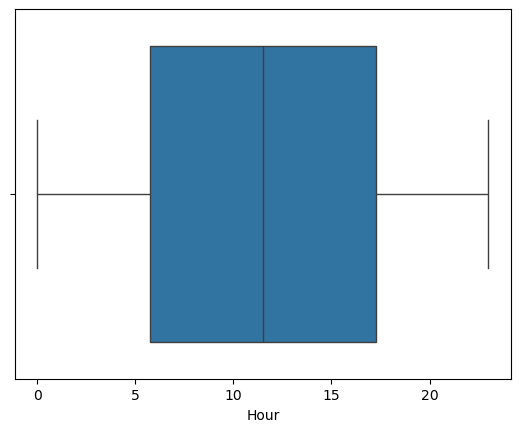

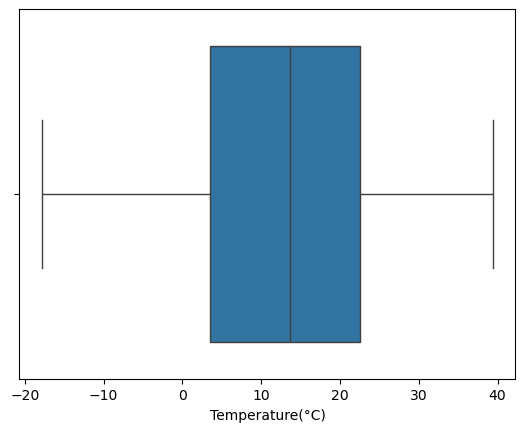

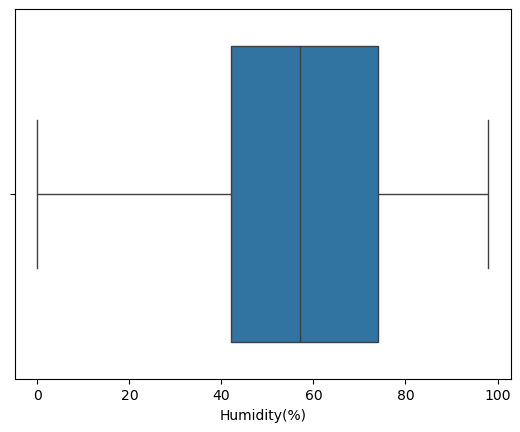

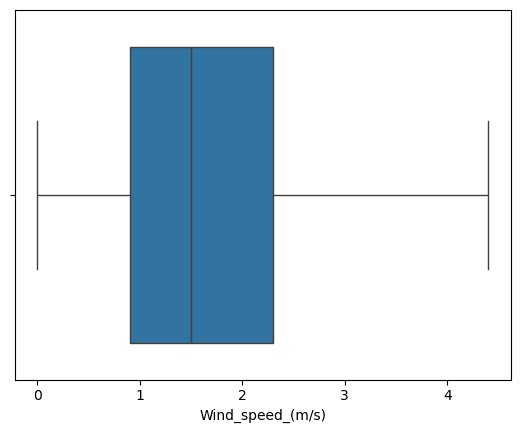

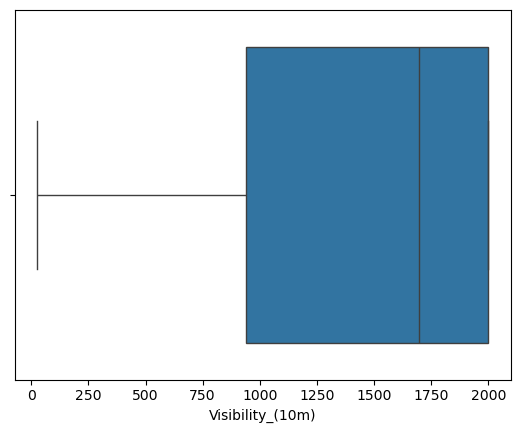

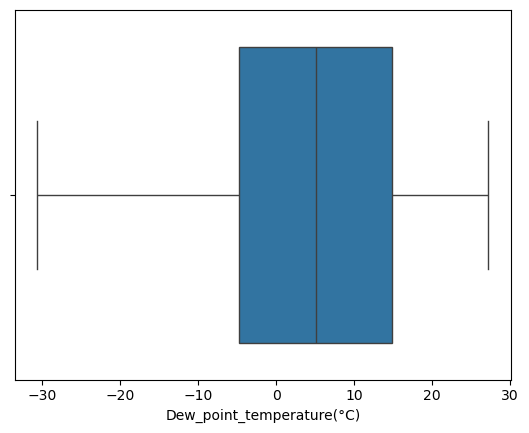

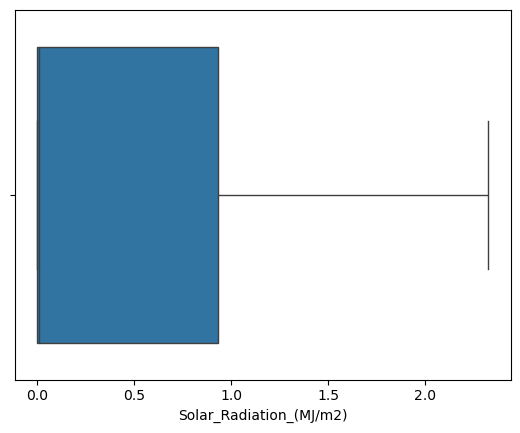

In [23]:
for i in [ 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind_speed_(m/s)', 'Visibility_(10m)', 'Dew_point_temperature(°C)',
       'Solar_Radiation_(MJ/m2)']:
    sns.boxplot(data=df,x=i)
    plt.show()

# bivariante

In [24]:
cor_df = cont_df.corr()

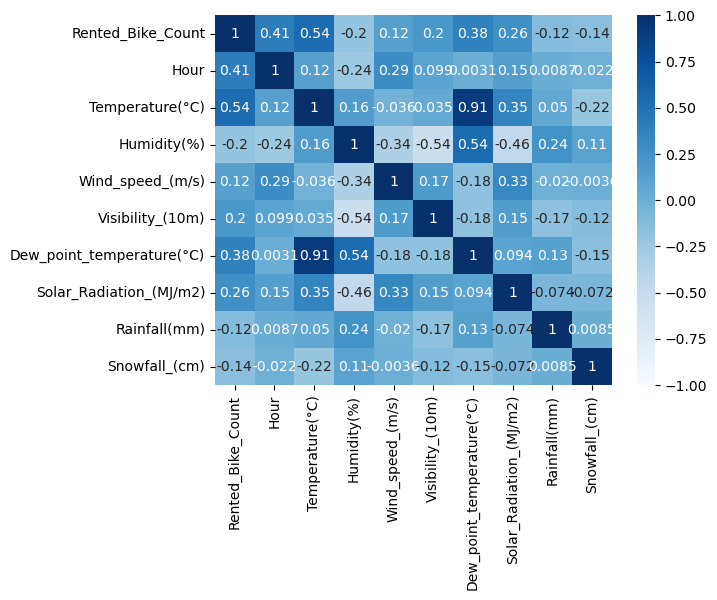

In [25]:
sns.heatmap(data=cor_df,vmin=-1,vmax=1,annot=True,cmap='Blues')
plt.show()

# ENCODING

In [26]:
df_cat.columns

Index(['Seasons', 'Holiday', 'Functioning_Day'], dtype='object')

In [27]:
df_cat = pd.get_dummies(data=df_cat,drop_first=True,dtype='int')


In [28]:
f_df = pd.concat([cont_df,df_cat],axis=1)

In [29]:
f_df.head()

,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind_speed_(m/s),Visibility_(10m),Dew_point_temperature(°C),Solar_Radiation_(MJ/m2),Rainfall(mm),Snowfall_(cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,0,1,1,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,0,1,1,1


# Featue engineering

In [30]:
f_df['Year']=df.Date.dt.year
f_df['month']=df.Date.dt.month

In [31]:
f_df['day_of_week'] = df.Date.dt.day_of_week

In [32]:
f_df['isweekend'] = np.where(f_df.day_of_week>=5 ,1,0)

In [33]:
f_df.head()

,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind_speed_(m/s),Visibility_(10m),Dew_point_temperature(°C),Solar_Radiation_(MJ/m2),Rainfall(mm),Snowfall_(cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes,Year,month,day_of_week,isweekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1,2017,12,4,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1,2017,12,4,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,0,1,1,1,2017,12,4,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,0,1,1,1,2017,12,4,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,0,1,1,1,2017,12,4,0


# multicolinearity
f_df.columns

In [34]:
def vif_cal(Z):
    x_var =Z
    xvar_names = Z.columns
    vif = pd.DataFrame()
    for i in range(0, xvar_names.shape[0]):
        y=x_var[xvar_names[i]]
        x = x_var[xvar_names.drop(xvar_names[i])]
        rsq =smf.ols(formula ="y~x", data =x_var).fit().rsquared
        vif = round(1/(1-rsq),2)
        print(xvar_names[i], 'VIF = ' , vif)

In [35]:
vif_cal(Z = f_df[['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind_speed_(m/s)',
       'Visibility_(10m)', 'Dew_point_temperature(°C)',
       'Solar_Radiation_(MJ/m2)', 'Rainfall(mm)', 'Snowfall_(cm)',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday', 'Functioning_Day_Yes', 'Year', 'month',
       'day_of_week', 'isweekend']])

Hour VIF =  1.21
Temperature(°C) VIF =  90.19
Humidity(%) VIF =  20.68
Wind_speed_(m/s) VIF =  1.31
Visibility_(10m) VIF =  1.69
Dew_point_temperature(°C) VIF =  118.18
Solar_Radiation_(MJ/m2) VIF =  2.04
Rainfall(mm) VIF =  1.09
Snowfall_(cm) VIF =  1.13
Seasons_Spring VIF =  14.27
Seasons_Summer VIF =  6.04
Seasons_Winter VIF =  28.08
Holiday_No Holiday VIF =  1.03
Functioning_Day_Yes VIF =  1.08
Year VIF =  17.48
month VIF =  22.21
day_of_week VIF =  2.67
isweekend VIF =  2.67


In [36]:
vif_cal(Z = f_df[['Hour', 'Temperature(°C)', 'Wind_speed_(m/s)',
       'Visibility_(10m)', 
       'Solar_Radiation_(MJ/m2)', 'Rainfall(mm)', 'Snowfall_(cm)',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday', 'Functioning_Day_Yes', 'month',
       'day_of_week', 'isweekend']])

Hour VIF =  1.16
Temperature(°C) VIF =  5.01
Wind_speed_(m/s) VIF =  1.3
Visibility_(10m) VIF =  1.16
Solar_Radiation_(MJ/m2) VIF =  1.42
Rainfall(mm) VIF =  1.04
Snowfall_(cm) VIF =  1.1
Seasons_Spring VIF =  2.69
Seasons_Summer VIF =  2.9
Seasons_Winter VIF =  3.84
Holiday_No Holiday VIF =  1.03
Functioning_Day_Yes VIF =  1.08
month VIF =  1.82
day_of_week VIF =  2.66
isweekend VIF =  2.66


In [37]:
f_df=f_df[['Rented_Bike_Count','Hour', 'Temperature(°C)',  'Wind_speed_(m/s)',
       'Visibility_(10m)',
       'Solar_Radiation_(MJ/m2)', 'Rainfall(mm)', 'Snowfall_(cm)',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday', 'Functioning_Day_Yes',  'month',
       'day_of_week', 'isweekend']]

In [38]:
f_df

,Rented_Bike_Count,Hour,Temperature(°C),Wind_speed_(m/s),Visibility_(10m),Solar_Radiation_(MJ/m2),Rainfall(mm),Snowfall_(cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes,month,day_of_week,isweekend
0,254,0,-5.2,2.2,2000,0.0,0.0,0.0,0,0,1,1,1,12,4,0
1,204,1,-5.5,0.8,2000,0.0,0.0,0.0,0,0,1,1,1,12,4,0
2,173,2,-6.0,1.0,2000,0.0,0.0,0.0,0,0,1,1,1,12,4,0
3,107,3,-6.2,0.9,2000,0.0,0.0,0.0,0,0,1,1,1,12,4,0
4,78,4,-6.0,2.3,2000,0.0,0.0,0.0,0,0,1,1,1,12,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,2.6,1894,0.0,0.0,0.0,0,0,0,1,1,11,4,0
8756,764,20,3.4,2.3,2000,0.0,0.0,0.0,0,0,0,1,1,11,4,0
8757,694,21,2.6,0.3,1968,0.0,0.0,0.0,0,0,0,1,1,11,4,0
8758,712,22,2.1,1.0,1859,0.0,0.0,0.0,0,0,0,1,1,11,4,0


# feature selection
### SELECTKBEST

In [39]:
X = f_df.drop('Rented_Bike_Count',axis=1)
y=f_df.Rented_Bike_Count 

In [40]:
selection = SelectKBest(score_func = f_regression , k='all' )
sel = selection.fit(X,y)

In [41]:
sel.scores_

array([1772.37911376, 3577.99111383,  130.36797042,  362.18665911,
        644.63130417,  134.69949406,  179.72217677,    4.59046295,
        844.45442014, 1929.8040989 ,   46.06926092,  380.07667914,
        158.95332838,    7.55459156,   11.66253112])

In [42]:
pd.DataFrame({'Features' : X.columns, 'scores' : sel.scores_}).sort_values(by='scores',ascending=False)

,Features,scores
1,Temperature(°C),3577.991114
9,Seasons_Winter,1929.804099
0,Hour,1772.379114
8,Seasons_Summer,844.454420
4,Solar_Radiation_(MJ/m2),644.631304
11,Functioning_Day_Yes,380.076679
3,Visibility_(10m),362.186659
6,Snowfall_(cm),179.722177
12,month,158.953328
5,Rainfall(mm),134.699494


# feature_selection --

#### RFE

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

In [44]:
model = LinearRegression()

rfe = RFE(estimator=model , n_features_to_select=10).fit(X,y)


In [45]:
pd.DataFrame({'Features':X.columns , 'Ranking' : rfe.ranking_}).sort_values(by='Ranking',ascending=True)

,Features,Ranking
0,Hour,1
2,Wind_speed_(m/s),1
6,Snowfall_(cm),1
5,Rainfall(mm),1
7,Seasons_Spring,1
10,Holiday_No Holiday,1
9,Seasons_Winter,1
8,Seasons_Summer,1
14,isweekend,1
11,Functioning_Day_Yes,1


In [46]:
X.columns

Index(['Hour', 'Temperature(°C)', 'Wind_speed_(m/s)', 'Visibility_(10m)',
       'Solar_Radiation_(MJ/m2)', 'Rainfall(mm)', 'Snowfall_(cm)',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday', 'Functioning_Day_Yes', 'month', 'day_of_week',
       'isweekend'],
      dtype='object')

In [47]:
X=X[['Hour',  'Wind_speed_(m/s)',
       'Rainfall(mm)', 'Snowfall_(cm)',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday', 'Functioning_Day_Yes', 
       'isweekend']]

# train-test-split

In [48]:
Xtrain ,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=6)

# SCALING

In [49]:
Xtrain.columns

Index(['Hour', 'Wind_speed_(m/s)', 'Rainfall(mm)', 'Snowfall_(cm)',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday', 'Functioning_Day_Yes', 'isweekend'],
      dtype='object')

In [50]:
num_cols = ['Hour', 'Wind_speed_(m/s)', 'Rainfall(mm)', 'Snowfall_(cm)']

In [51]:
ss= StandardScaler()

In [52]:
Xtrain[num_cols] = ss.fit_transform(Xtrain[num_cols])
Xtest[num_cols] = ss.transform(Xtest[num_cols])

In [53]:
Xtrain.head()

,Hour,Wind_speed_(m/s),Rainfall(mm),Snowfall_(cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes,isweekend
2030,0.359382,0.369918,-0.129008,-0.173373,0,0,1,1,1,0
5247,0.503612,-0.404478,-0.129008,-0.173373,0,1,0,1,1,1
3480,-1.659840,-0.985275,-0.129008,-0.173373,1,0,0,1,1,0
7856,-0.505999,-0.501277,-0.129008,-0.173373,0,0,0,1,1,0
8642,-1.371380,-0.598077,-0.129008,0.524366,0,0,0,1,1,0


In [54]:
Xtest.head()

,Hour,Wind_speed_(m/s),Rainfall(mm),Snowfall_(cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes,isweekend
7307,-0.073309,2.693106,-0.129008,-0.173373,0,0,0,1,1,0
2459,-0.073309,-0.307678,-0.129008,-0.173373,1,0,0,1,1,0
4736,-0.505999,-0.694876,-0.129008,-0.173373,0,1,0,1,1,1
6161,0.792072,1.241114,-0.129008,-0.173373,0,1,0,1,1,0
5775,0.503612,0.176319,-0.129008,-0.173373,0,1,0,1,1,1


# modelling

In [55]:
m1 = LinearRegression().fit(Xtrain,ytrain)

In [56]:
train_pred = m1.predict(Xtrain)
test_pred = m1.predict(Xtest)

## performance check

## training

In [57]:
np.sqrt(metrics.mean_squared_error(ytrain,train_pred))

np.float64(468.3667172649256)

In [58]:
metrics.r2_score(ytrain,train_pred)

0.4667604580123148

## testing

In [59]:
np.sqrt(metrics.mean_squared_error(ytest,test_pred))

np.float64(477.321513315594)

In [60]:
metrics.r2_score(ytest,test_pred)

0.47534931775100575

In [61]:
m1.coef_

array([ 247.46053766,   45.9097654 ,  -98.18114164,  -25.13217569,
       -193.73069682,  101.64708705, -715.23007844,   48.40248099,
        897.96263661,  -61.4029543 ])

In [62]:
m1.intercept_

np.float64(7.518486989361577)

## ridge regression (l2)

In [63]:
m2 = Ridge().fit(Xtrain,ytrain)

In [64]:
train_pred1 =m2.predict(Xtrain)
test_pred1 = m2.predict(Xtest)

In [65]:
#performance check
#training 

In [66]:
np.sqrt(metrics.mean_squared_error(ytrain,train_pred1))

np.float64(468.3674909167341)

In [67]:
metrics.r2_score(ytrain,train_pred1)

0.466758696392364

In [68]:
#testing performance `

In [69]:
np.sqrt(metrics.mean_squared_error(ytest,test_pred1))

np.float64(477.32243617280227)

In [70]:
metrics.r2_score(ytest,test_pred1)

0.4753472890214452

In [71]:
m2.coef_

array([ 247.45111941,   45.84150174,  -98.15993747,  -25.16048484,
       -192.73412295,  102.56230819, -713.79904694,   48.36743622,
        893.54968028,  -61.28309757])

In [72]:
m2.intercept_

np.float64(10.945425885949703)

## lasso regression (l1)

In [73]:
m3 = Lasso().fit(Xtrain,ytrain)


In [74]:
train_pred2 =m3.predict(Xtrain)
test_pred2 = m3.predict(Xtest)

In [75]:
#perfromance check 

In [76]:
#training 

In [77]:
np.sqrt(metrics.mean_squared_error(ytrain,train_pred2))

np.float64(468.4583162793093)

In [78]:
metrics.r2_score(ytrain,train_pred2)

0.4665518650831615

In [79]:
#testing 

In [80]:
np.sqrt(metrics.mean_squared_error(ytest,test_pred2))

np.float64(477.77205739072286)

In [81]:
metrics.r2_score(ytest,test_pred2)

0.4743584140997166

In [82]:
m3.coef_

array([ 247.00040284,   44.21921295,  -97.02328699,  -24.2818851 ,
       -181.35713152,  106.67142976, -703.39527477,   26.62464154,
        863.16609837,  -55.57065615])

In [83]:
m3.intercept_

np.float64(52.89590265863069)

## elasticnet

In [84]:
m4 = ElasticNet(random_state=10).fit(Xtrain,ytrain)

In [85]:
train_pred3 =m4.predict(Xtrain)
test_pred3 = m4.predict(Xtest)

In [86]:
#perfromance check 
#training

In [87]:
np.sqrt(metrics.mean_squared_error(ytrain,train_pred3))

np.float64(540.5883530223257)

In [88]:
metrics.r2_score(ytrain,train_pred3)

0.2896315511216443

In [89]:
#testing

In [90]:
np.sqrt(metrics.mean_squared_error(ytest,test_pred3))

np.float64(553.2164197334123)

In [91]:
metrics.r2_score(ytest,test_pred3)

0.29524470479980147

In [92]:
m4.coef_

array([ 1.68394768e+02,  2.68415078e+01, -5.63100423e+01, -4.53995420e+01,
       -1.14059521e-01,  1.02927936e+02, -1.57571864e+02,  1.13672037e+01,
        4.68268433e+01, -1.29733393e+01])

In [93]:
m4.intercept_

np.float64(666.1158906897164)

# gridsearch

In [94]:
from sklearn.model_selection import GridSearchCV

In [95]:
#Ridge

In [96]:
param_grid = {
    'alpha': [0.01,0.1,10,100]
}

grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(Xtrain, ytrain)

print("Best Params:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)

Best Params: {'alpha': 0.1}
Best RMSE: 468.9223793687758


In [97]:
# lasso

In [98]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
    
}

grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(Xtrain, ytrain)

print("Best Params:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)

Best Params: {'alpha': 0.1}
Best RMSE: 468.92181981006115


In [99]:
#elasticnet

In [100]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.9]
}

grid = GridSearchCV(ElasticNet(random_state=42), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(Xtrain, ytrain)

print("Best Params:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)

Best Params: {'alpha': 0.01, 'l1_ratio': 0.9}
Best RMSE: 468.9523569664178
